In [1]:
import numpy as np
import matplotlib.pyplot as plt

from cifar10_data_preprocessing import *

In [2]:
data_dir = 'cifar-10-batches-py'

# Load cifar-10 dataset.
train_data, train_labels, test_data, test_labels, label_names = load_data(data_dir)

# Shuffle the train_data and divide into train_data and dev_data.
# num_dev indicates the number of image data in dev set.
dev_data, dev_labels, train_data, train_labels = split_dataset(train_data, train_labels, num_dev = 5000)

# Check the shape of train/dev/test data and number of classes.
print("Train data: ", train_data.shape)
print("Train labels: ", train_labels.shape)
print("Dev data: ", dev_data.shape)
print("Dev labels: ", dev_labels.shape)
print("Test data: ", test_data.shape)
print("Test labels: ", test_labels.shape)
print('Number of classes:', label_names.shape[0])

Train data:  (45000, 32, 32, 3)
Train labels:  (45000,)
Dev data:  (5000, 32, 32, 3)
Dev labels:  (5000,)
Test data:  (10000, 32, 32, 3)
Test labels:  (10000,)
Number of classes: 10


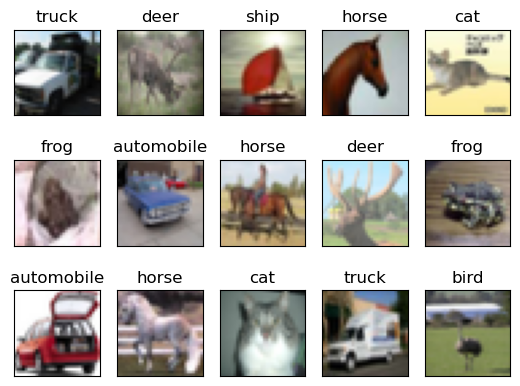

In [3]:
# Don't forget that the label_names and filesnames are in binary and need conversion if used.
classes = np.array(['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])

# Display some random training images in a 3x5 grid
fig, ax = plt.subplots(3, 5)
for m in range(3):
    for n in range(5):
        idx = np.random.randint(0, train_data.shape[0])
        ax[m, n].set_title(classes[train_labels[idx]]) # display label
        ax[m, n].imshow(train_data[idx]) # display image data
        ax[m, n].get_xaxis().set_visible(False)
        ax[m, n].get_yaxis().set_visible(False)
plt.show()

In [4]:
# Convert label of each image data into one-hot vector(y). 
# Its length is the same as the number of classes.
y_train = one_hot_encoding(train_labels, classes)
y_dev = one_hot_encoding(dev_labels, classes)
y_test = one_hot_encoding(test_labels, classes)

print(y_train[0])
print(y_train.shape)

[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
(45000, 10)


In [5]:
# Normalize pixel values of input image from [0, 255] range to [0, 1] range.
x_train = normalize_image(train_data)
x_dev = normalize_image(dev_data)
x_test = normalize_image(test_data)

print(train_data[0]) # before normalization
print(x_train[0]) # after normalization
print(x_train[0].dtype)

[[[125 127 114]
  [127 129 116]
  [127 129 118]
  ...
  [ 85 104  33]
  [ 82 102  25]
  [ 82 103  23]]

 [[130 132 119]
  [132 134 122]
  [131 132 122]
  ...
  [ 89 105  37]
  [ 90 106  34]
  [ 93 110  35]]

 [[132 134 123]
  [134 136 125]
  [132 134 124]
  ...
  [ 85  95  32]
  [ 87  98  34]
  [ 93 106  40]]

 ...

 [[125 127 114]
  [130 132 119]
  [133 135 122]
  ...
  [109 109 106]
  [113 114 108]
  [119 120 112]]

 [[124 126 113]
  [127 129 116]
  [135 137 124]
  ...
  [104 104 101]
  [108 109 104]
  [119 120 112]]

 [[137 138 126]
  [139 141 129]
  [141 143 131]
  ...
  [101 102  98]
  [107 108 102]
  [118 119 111]]]
[[[0.44878048 0.4278846  0.3991228 ]
  [0.4585366  0.4375     0.40789473]
  [0.4585366  0.4375     0.41666666]
  ...
  [0.25365853 0.31730768 0.04385965]
  [0.23902439 0.30769232 0.00877193]
  [0.23902439 0.3125     0.        ]]

 [[0.47317073 0.45192307 0.42105263]
  [0.48292682 0.46153846 0.43421054]
  [0.47804877 0.45192307 0.43421054]
  ...
  [0.27317074 0.3221154